In [1]:
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt


from src.d_CSL import *
from src.dataload import *

# if variables are changed on the fly 
from reloading import reloading
from tqdm.notebook import tqdm

No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


In [2]:
%reload_ext autoreload
%autoreload 2
from src.d_CSL import *

## Simulate data

An example ground truth connectivity matrix `A`

In [3]:
np.random.seed(3465)
n_neur=30
A = np.random.choice([0,0.5,0.85], p=[0.9,0.03,0.07], size=(n_neur,n_neur)) ### A is not the adjacency matrix in the typical sense
A = 0.5*(A)
A[0:10,0:10] =np.zeros((10,10))
for n, i in enumerate(A):
    A[n][n]=1
for n, i in enumerate(A):
    A[n]=A[n]/np.sum(A[n])
A.shape

(30, 30)

Text(0.5, 1.0, 'GT')

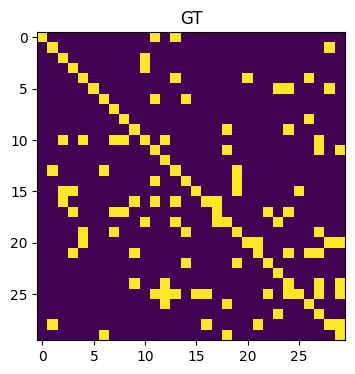

In [4]:
plt.figure(figsize=(4,4))
plt.imshow(A.T!=0)
plt.title('GT')

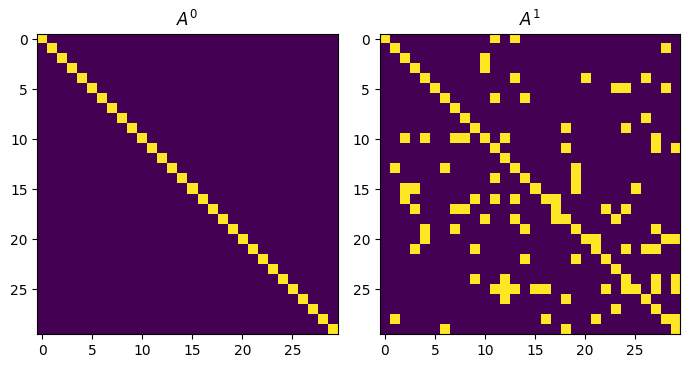

In [5]:
fig,ax = plt.subplots(1,2,figsize=(7,4))
ax[0].imshow(np.eye(30))
ax[0].set_title('$A^{0}$')
ax[1].imshow(A.T!=0)
ax[1].set_title('$A^{1}$')

plt.tight_layout()

In [6]:
def continuous_noise_fun(num, l=5000):
    xx = np.linspace(0,500,l)
    noise = np.zeros((num,l))
    for i in range(num):
        a = 2*np.random.normal(0,0.25,size=6)
        c = 500*(np.random.random(size=6))
        s = 1+100*(np.random.random(size=6))
        yy = 0*xx
        for j in range(6):
            yy = yy + a[j]*np.exp(-(xx-c[j])**2/s[j]) 
        noise[i] = yy
    return noise 
np.random.seed(13)

noise = continuous_noise_fun(num=n_neur, l=5000)

In [7]:
noise.shape

(30, 5000)

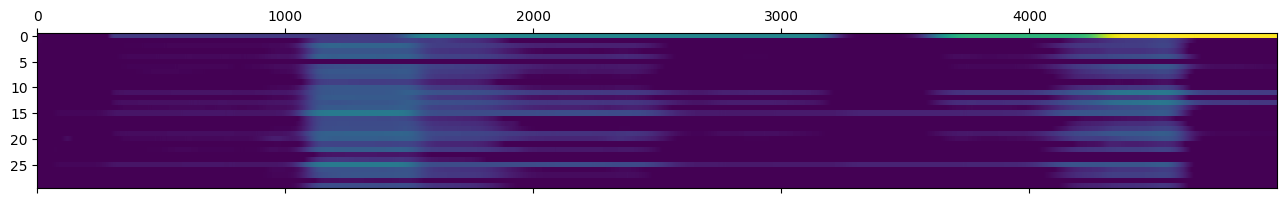

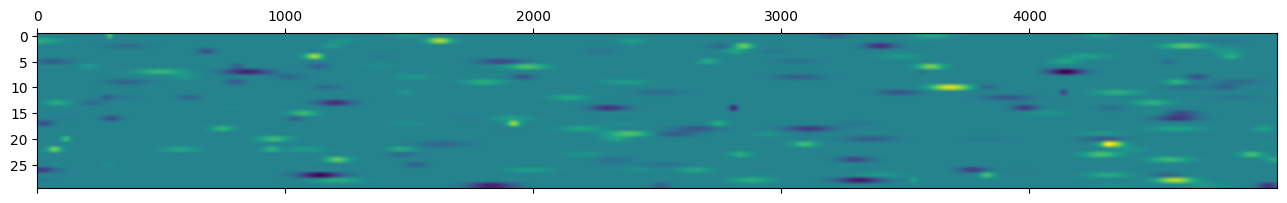

In [8]:
X = np.zeros([A.shape[0],5000]).T
X[0] = np.random.randn(A.shape[0])
for i, row in enumerate(X[:-1]):
    X[i+1] = A @ X[i] + 0.05 * np.random.normal(0,0.25,A.shape[0]) + noise[:,i]
X=X.T
plt.matshow(X, aspect='auto',vmin=0)
plt.matshow(noise, aspect='auto', interpolation=None)

## Analysis

In [9]:
N_PASTS, n_lags, n_perm = np.arange(1, 8, 1), 1, 1000
alpha, beta = 0.05, 0.001

In [10]:
infs_fgc = []
conf_mtx_fgc = []
shds_fgc = []
metrics_fgc = []
# for i, n in enumerate(N_PASTS):
for i in range(10):
    print(f'{i}')
    gcstar = GcStar(n_perm = 1000, 
                    n_pasts = 3,
                    n_lags = n_lags,
                    temporal = True,
                    method = 'fcgc')
    
    gcstar.fit(X, verbose = 0)
    inf = gcstar.get_connectivity_matrix(alpha=alpha, beta=beta, simulation=True)
    infs_fgc.append(inf)
    conf_mtx_fgc.append(gcstar.compute_confusion_matrix(A, simulation=True))
    metrics_fgc.append(np.round(gcstar.all_metrics(),4))
    shds_fgc.append(np.round(gcstar.compute_shd_sid(A, inf, simulation=True),4))

0
1
2
3
4
5
6
7
8
9


In [11]:
print(shds_fgc)
np.round(metrics_fgc,4)

[np.float64(73.0709), np.float64(74.0657), np.float64(75.0596), np.float64(76.4179), np.float64(75.731), np.float64(75.6745), np.float64(75.5199), np.float64(75.4864), np.float64(71.9447), np.float64(75.6302)]


array([[0.9956, 0.9826, 0.9826, 0.0025, 0.99  , 0.9826],
       [0.9922, 0.9655, 0.9739, 0.0051, 0.9844, 0.9697],
       [0.9911, 0.9573, 0.9739, 0.0064, 0.9838, 0.9655],
       [0.9933, 0.958 , 0.9913, 0.0064, 0.9925, 0.9744],
       [0.9922, 0.9576, 0.9826, 0.0064, 0.9881, 0.97  ],
       [0.9922, 0.9576, 0.9826, 0.0064, 0.9881, 0.97  ],
       [0.9944, 0.9661, 0.9913, 0.0051, 0.9931, 0.9785],
       [0.9944, 0.9661, 0.9913, 0.0051, 0.9931, 0.9785],
       [0.9967, 0.9912, 0.9826, 0.0013, 0.9907, 0.9869],
       [0.9944, 0.9661, 0.9913, 0.0051, 0.9931, 0.9785]])

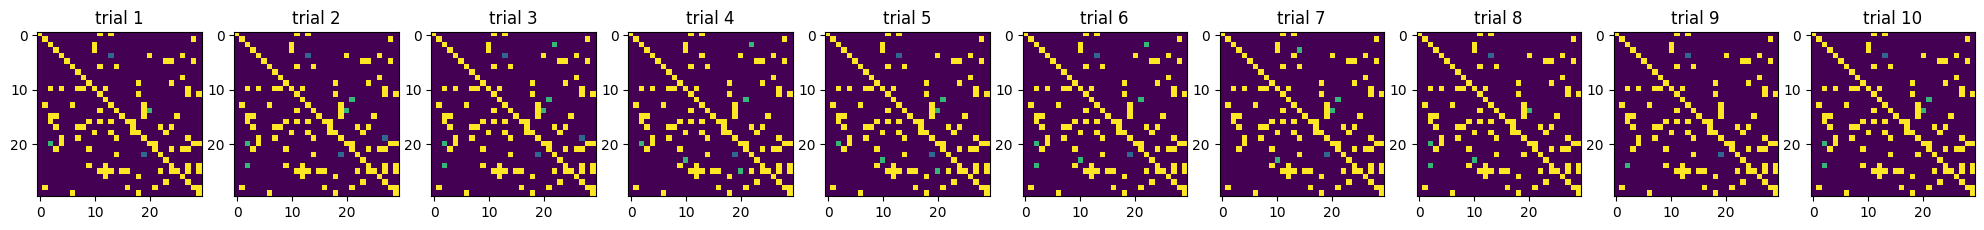

In [12]:
fig, axes = plt.subplots(1,len(infs_fgc), figsize=(2.5*len(infs_fgc),3)) 
for i, ax in enumerate(axes):
    ax.imshow(compare_with_GT(A, infs_fgc[i], simulation=True))
    ax.set_title(f'trial {i+1}')

In [13]:
print(np.mean(metrics_fgc, axis=0))
np.round(np.std(metrics_fgc, axis=0),4)

[0.99365 0.96681 0.98434 0.00498 0.98969 0.97546]


array([0.0017, 0.0109, 0.0065, 0.0017, 0.0033, 0.0063])

In [14]:
stop

NameError: name 'stop' is not defined

labels = ['Acc', 'Prec', 'Rec', 'FPR']
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for i in range(metrics.shape[1]):
    ax[i].plot(metrics[:, i], marker = '.', label = labels[i], c = 'blue')
    ax[i].set_xticks(np.arange(metrics.shape[0]), list(np.arange(1, 8, 1)))
    ax[i].set_xlabel('$n_{pasts}$')
    ax[i].set_ylabel('%', rotation = 180)
    ax[i].set_title(f'{labels[i]}')
plt.tight_layout()